# 📌 Outliers in Machine Learning

~~~ ticks

 Data
   └─➤ Handle Missing Values
   └─➤ Encode Categorical Features
   └─➤ Detect and Treat Outliers
   └─➤ Scale Numerical Features
   └─➤ Feed into ML Model




## 💡 What are Outliers?
Outliers are data points that differ significantly from other observations in a dataset. They may arise due to:
- Measurement errors
- Data entry mistakes
- Natural deviations
- Fraudulent activity

**Example:**  
If most salaries range between ₹30,000 and ₹70,000, but one person earns ₹1,00,00,000 — that's an outlier.

---

## 🎯 Effect of Outliers on Machine Learning Models

| Impact Area                        | Effect                                                                 |
|-----------------------------------|------------------------------------------------------------------------|
| Mean & Standard Deviation         | Strongly influenced by outliers                                        |
| Linear Models (Regression)        | Coefficients become unstable                                           |
| Distance-based Models (KNN, SVM)  | Outliers distort distance calculations                                 |
| Clustering (K-Means, DBSCAN)      | Centroids and clusters get skewed                                      |
| Tree-based Models (Decision Trees, Random Forests) | Less affected, more robust                            |

---

## 🔎 How to Detect Outliers

### 1. **Visualization Techniques**
- **Box Plot**: Highlights values outside 1.5 × IQR
- **Histogram/Density Plot**: Identifies skewed distributions
- **Scatter Plot**: Detects multivariate outliers

---

### 2. **Statistical Techniques**

#### a. Z-Score Method(Normally distributed data)
Measures the number of standard deviations a value is from the mean:

Z = (x - mu)/sigma

- Rule of Thumb: |Z| > 3 → Potential outlier

#### b. IQR Method (Interquartile Range)(Skewed)

\[
IQR = Q3 - Q1
\]

- Lower Bound = Q1 - 1.5 × IQR  
- Upper Bound = Q3 + 1.5 × IQR  
- Values outside this range are considered outliers

---

### 3. **ML-Based Techniques**

#### a. Isolation Forest
- Splits data points randomly; outliers are isolated faster.

#### b. Local Outlier Factor (LOF)
- Compares local density of a point with its neighbors.

#### c. DBSCAN
- Clusters dense areas and labels low-density points as noise.

#### d. One-Class SVM
- Learns the boundary of normal data and identifies outliers.

---

## 🛠️ How to Treat Outliers

| Method                | Description                                                                 |
|-----------------------|-----------------------------------------------------------------------------|
| **Remove**            | Drop the rows entirely (can lead to data loss)                              |
| **Cap (Winsorize)**   | Limit extreme values to 5th and 95th percentile                             |
| **Transformation**    | Apply `log`, `sqrt`, or Box-Cox to reduce skewness                          |
| **Impute**            | Replace outlier values with median or mean                                  |
| **Robust Models**     | Use models like Random Forest, which are not affected by outliers           |
| **Anomaly Detection** | Train a separate model to detect/focus on the outliers (e.g., fraud cases)  |

---

## 📘 Summary

| Task               | Techniques                             |
|--------------------|-----------------------------------------|
| **Detect**         | Boxplot, Z-score, IQR, LOF, Isolation Forest |
| **Impact on ML**   | Bias coefficients, distort distances, reduce accuracy |
| **Treat**          | Remove, Cap, Transform, Impute, Use Robust Models |

---



In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
cwd=os.getcwd()
data_dir=os.path.join(cwd,'Data')
file_name='outlier_detection_dataset.csv'
file_path=os.path.join(data_dir,file_name)

In [3]:
df_outlier=pd.read_csv(file_path)
df_outlier

,Normal_Feature1,Normal_Feature2,Skewed_Feature1,Skewed_Feature2
0,54.967142,81.086741,20.764492,6.006525
1,48.617357,113.767929,16.915634,9.550796
2,56.476885,131.832343,8.804135,17.846355
3,65.230299,115.486979,86.123915,6.241234
4,47.658466,77.209451,18.616660,19.571245
...,...,...,...,...
248,67.654542,86.865726,34.013918,3.453884
249,54.049817,79.258004,8.365456,42.550926
250,150.000000,-10.000000,200.000000,180.000000
251,160.000000,-20.000000,220.000000,190.000000


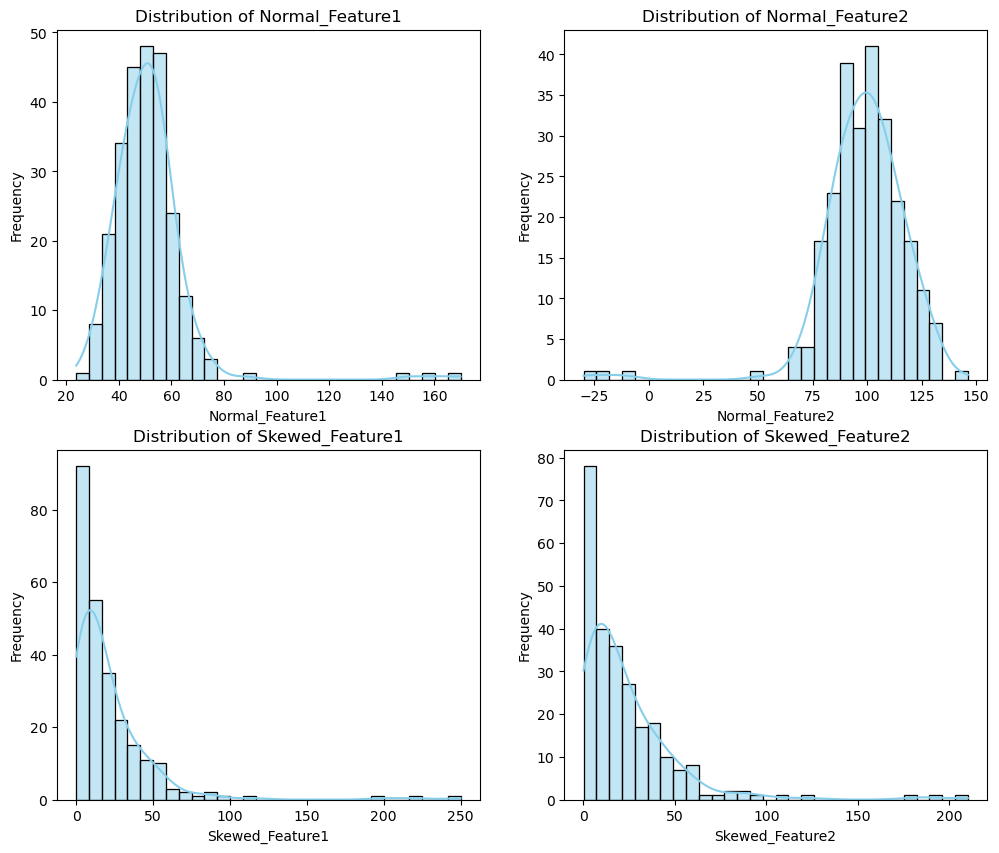

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10) ) # 2 rows, 2 columns
axes = axes.flatten()  # Flatten 2D array to 1D for easy looping

# Plot each distribution
for idx, col in enumerate(df_outlier.columns):
    sns.histplot(df_outlier[col], kde=True, ax=axes[idx], color='skyblue', bins=30)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

In [5]:
df_outlier.skew()


Normal_Feature1    4.315797
Normal_Feature2   -2.475907
Skewed_Feature1    4.513367
Skewed_Feature2    3.393454
dtype: float64

<Axes: title={'center': 'Boxplots of All Columns'}>

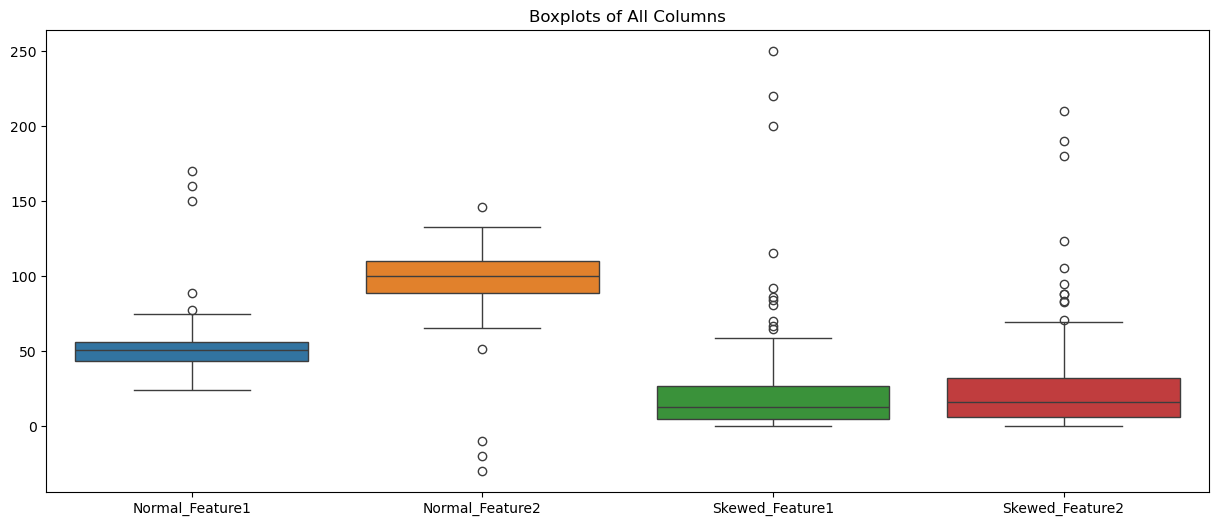

In [6]:
plt.figure(figsize=(15, 6))
plt.title("Boxplots of All Columns")
sns.boxplot(data=df_outlier)

## Normally distributed data

In [7]:

file_name='placement.csv'
file_path=os.path.join(data_dir,file_name)

In [8]:
df=pd.read_csv(file_path)
df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
998,8.62,46.0,1


In [9]:
df.describe()

,cgpa,placement_exam_marks,placed
count,1000.000000,1000.000000,1000.000000
mean,6.961240,32.225000,0.489000
std,0.615898,19.130822,0.500129
min,4.890000,0.000000,0.000000
25%,6.550000,17.000000,0.000000
50%,6.960000,28.000000,0.000000
75%,7.370000,44.000000,1.000000
max,9.120000,100.000000,1.000000


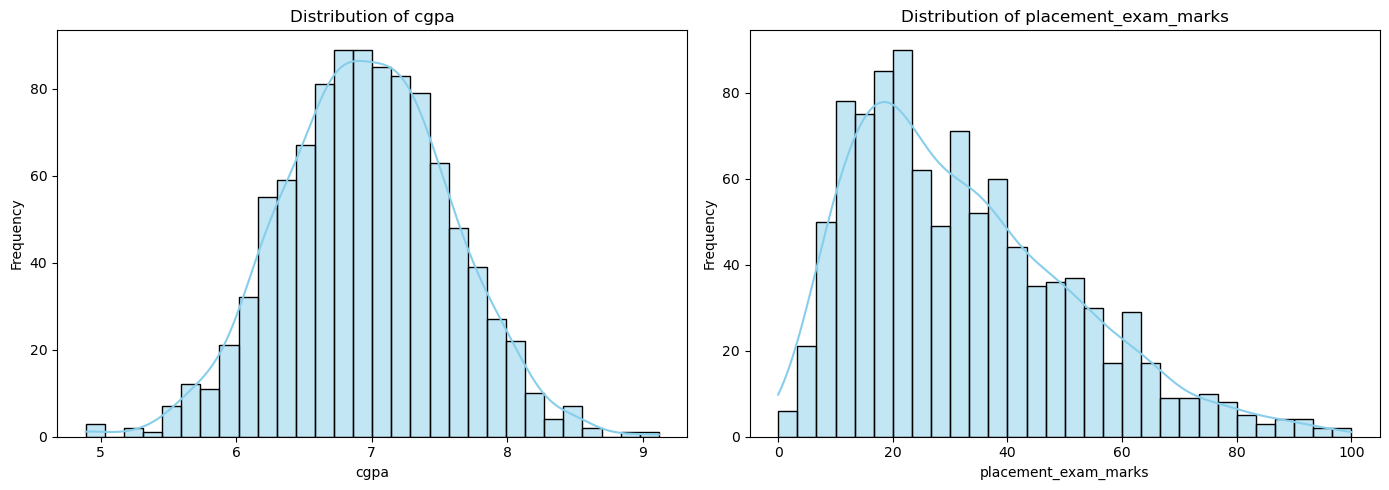

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns

# Plot each distribution
for idx, col in enumerate(df.columns[:-1]):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue', bins=30)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [11]:
df.drop('placed',axis=1).skew()

cgpa                   -0.014530
placement_exam_marks    0.835642
dtype: float64

In [12]:
mean_cgpa=df['cgpa'].mean()
mean_cgpa



6.96124

In [13]:
std_cgpa=df['cgpa'].std()
std_cgpa

0.6158978751323894

In [14]:
min_cgpa=df['cgpa'].min()
min_cgpa

4.89

In [15]:
max_cgpa=df['cgpa'].max()
max_cgpa

9.12

In [16]:
print ("Highest allowd:",mean_cgpa + 3* std_cgpa)
print ("lowest allowd:",mean_cgpa - 3* std_cgpa)

Highest allowd: 8.808933625397168
lowest allowd: 5.113546374602832


In [17]:
upper_cgpa=mean_cgpa + 3* std_cgpa
lower_cgpa=mean_cgpa - 3* std_cgpa

In [18]:
df['cgpa'] = pd.to_numeric(df['cgpa'], errors='coerce')

In [19]:
# Outliers

df[((df['cgpa'])>( mean_cgpa + 3* std_cgpa)) |((df['cgpa'])<( mean_cgpa - 3* std_cgpa))]

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


In [20]:
# TRIMMING

new_df=df[((df['cgpa'])<( mean_cgpa + 3* std_cgpa)) & ((df['cgpa'])>( mean_cgpa - 3* std_cgpa))]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


In [21]:
print("upper_cgpa:", upper_cgpa, type(upper_cgpa))
print("lower_cgpa:", lower_cgpa, type(lower_cgpa))


upper_cgpa: 8.808933625397168 <class 'numpy.float64'>
lower_cgpa: 5.113546374602832 <class 'numpy.float64'>


In [22]:
import numpy as np
df['cgpa'] = np.where(
    df['cgpa'] > upper_cgpa, upper_cgpa,  # If cgpa is too high → cap it
    np.where(
        df['cgpa'] < lower_cgpa, lower_cgpa,  # If cgpa is too low → floor it
        df['cgpa']  # Otherwise → keep original
    )
)


In [23]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

## Skewed data